# Sota solvers and pruning techniques

In [302]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from stochastic_graph import StochasticGraph
from preprocessing import Reach, ArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Importing and using the new graph

We use a 5x5 grid network, 25 nodes in total

In [303]:
sys.path.append(os.path.abspath("../graph"))

from Grid_network_and_Gamma_distribution import Matrix

In [304]:
matrix = Matrix(5, 5, link_var_max=0.5)
adj_matrix, var_matrix = matrix.compute_matrices()

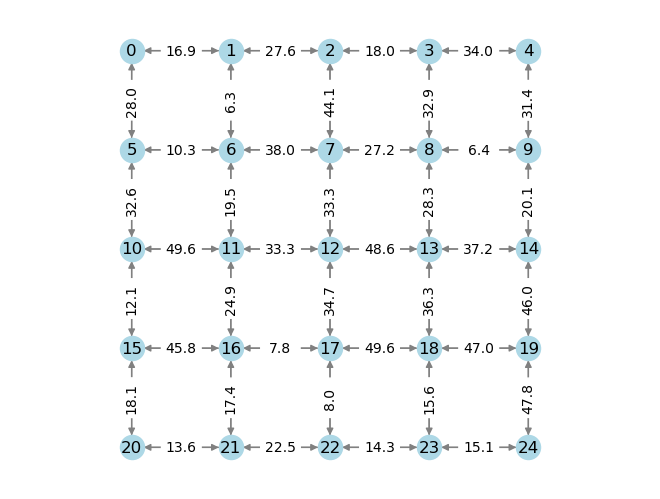

In [305]:
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
graph.print_graph(grid_shape=(5,5))

## Algorithms usage

In [315]:
destination_node = 20
time_budget = 300

### StandardSOTA

In [316]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

In [317]:
sota = StandardSOTASolver(graph, destination_node, time_budget)
sota.solve();

Convergence reached!
End of iterations


In [318]:
sota.print_sota_matrix()
sota.print_policy_matrix()

SOTA Matrix:
[[  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ...   0.06   0.06   0.06]
 [  0.00   0.00   0.00 ...   0.03   0.03   0.03]
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]]
Policy Matrix:
[[-1 -1 -1 ...  5  5  5]
 [-1 -1 -1 ...  6  6  6]
 [-1 -1 -1 ...  7  7  7]
 ...
 [-1 -1 21 ... 21 21 21]
 [-1 18 18 ... 22 22 22]
 [-1 -1 23 ... 23 23 23]]


In [319]:
sota.extract_path(3)

[3, 2, 7, 12, 17, 22, 21, 20]

### SingleIteration SOTA

In [340]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
sota2 = SingleIterationSOTASolver(graph, destination_node, time_budget)

In [341]:
sota2.solve()
sota2.print_sota_matrix()
sota2.print_policy_matrix()

SOTA Matrix:
[[  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ...   0.01   0.00   0.01]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]]
Policy Matrix:
[[-1 -1 -1 ...  5 -1  5]
 [-1 -1 -1 ...  2 -1  2]
 [-1 -1 -1 ...  7 -1  7]
 ...
 [-1 -1 -1 ... 21 -1 21]
 [-1 -1 -1 ... 22 -1 22]
 [-1 -1 -1 ... 23 -1 23]]


In [343]:
sota2.get_policy_matrix()[:,-1]

array([ 5,  2,  7,  2,  3, 10,  7, 12,  7, 14, 15, 16,  7, 12, 13, 20, 21,
       12, 23, 18, -1, 20, 21, 22, 23])

In [349]:
sota2.extract_path(3)

[3,
 2,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12,
 7,
 12]

### Precomputing techniques: Reach

In [296]:
r = Reach(graph, s)
r.reach_computation()

array([15.84079367, 15.84079367, 31.4187822 , 31.4187822 ,  0.        ,
       38.81636   , 35.68808041, 35.68808041, 39.7870747 , 34.86847107,
       42.45508691, 25.54266816, 38.42413413, 41.2088656 , 19.7212639 ,
       15.18478599, 14.48865298, 31.87823242, 34.85192704, 28.34327811,
       15.18478599, 34.52574271, 37.28763485, 37.28763485, 36.38753122])

In [297]:
r.reach_pruning()

Pruned nodes: {2, 4, 7, 15, 17}


{2, 4, 7, 15, 17}

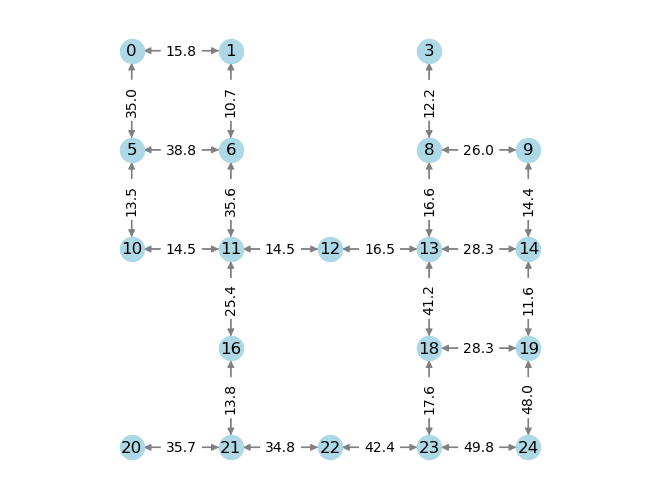

In [298]:
graph.print_graph()

In [295]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
s = SingleIterationSOTASolver(graph, destination_node, time_budget)

In [277]:
f = ArcFlags(graph, 4, s)
f.arcflags_computation()


{(np.int64(0), np.int64(1)): {0: False, 1: True, 2: True, 3: True},
 (np.int64(0), np.int64(5)): {0: False, 1: True, 2: True, 3: True},
 (np.int64(1), np.int64(0)): {0: False, 1: True, 2: True, 3: True},
 (np.int64(1), np.int64(2)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(1), np.int64(6)): {0: False, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(1)): {0: False, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(3)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(2), np.int64(7)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(3), np.int64(2)): {0: False, 1: True, 2: True, 3: True},
 (np.int64(3), np.int64(4)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(3), np.int64(8)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(4), np.int64(3)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(4), np.int64(9)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(5), np.int64(0)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(5), np.int64(6)): {0:

In [278]:
f.arcflags_pruning()

[ArcFlags] Pruned 45 edges for destination 24 (region 1).


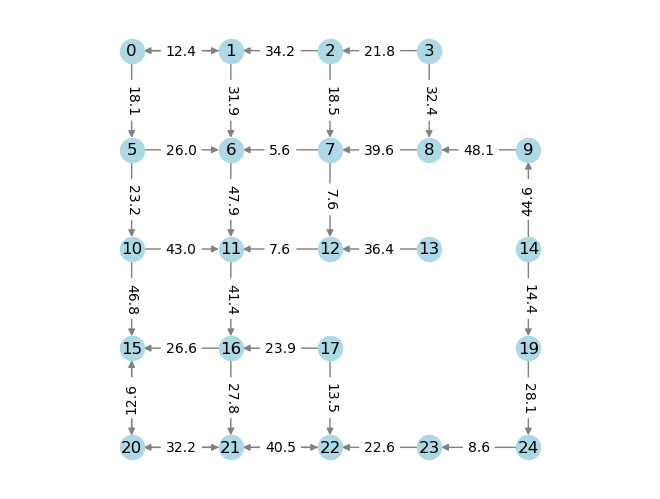

In [283]:
graph.print_graph()

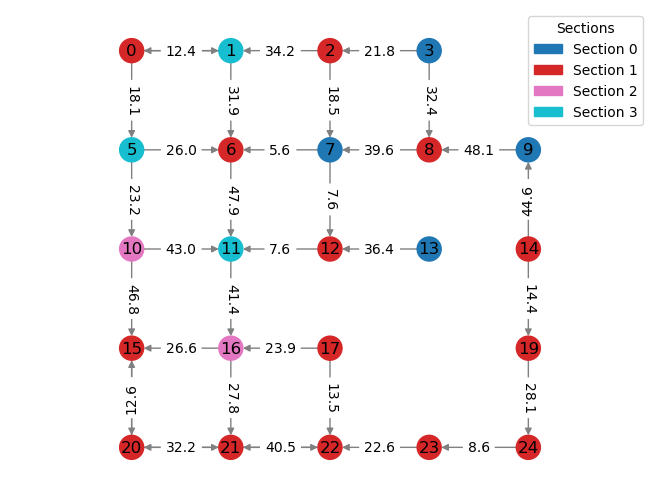

In [286]:
f.print_graph_sections()

In [196]:
import time

standard_sota = StandardSOTASolver(graph, destination_node, time_budget)
singleiteration_sota = SingleIterationSOTASolver(graph, destination_node, time_budget)

# standard SOTA execution
start = time.perf_counter()
standard_sota.solve()
end = time.perf_counter()
print(f"Standard SOTA exec time: {end-start:.6f} seconds")

# singleiteration SOTA execution
start = time.perf_counter()
singleiteration_sota.solve()
end = time.perf_counter()
print(f"Single Iteration SOTA exec time: {end-start:.6f} seconds")

# REACH pruning
# STANDARD
standard_sota = StandardSOTASolver(graph, destination_node, time_budget)
reach_standard = Reach(graph, standard_sota)

# Reach pruning technique execution
start = time.perf_counter()
reach_standard.reach_computation()
reach_standard.reach_pruning()
standard_sota.solve()
end = time.perf_counter()
print(f"Standard Reach pruning exec time: {end-start:.6f} seconds")

# SINGLEITERATION
singleiteration_sota = SingleIterationSOTASolver(graph, destination_node, time_budget)
reach_singleiteration = Reach(graph, singleiteration_sota)
start = time.perf_counter()
reach_singleiteration.reach_computation()
reach_singleiteration.reach_pruning()
singleiteration_sota.solve()
end = time.perf_counter()
print(f"Single iteration Reach exec time: {end-start:.6f} seconds")


KeyboardInterrupt: 